#### Modules

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

#### Convert categorical columns into numerical columns

In [7]:
#Upload dataset (we are not using carbon emission and fule comsumption comb as features)
df = pd.read_csv('Clean dataset.csv')
df = df.drop(columns = ['CO2 Emissions(g/km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)'])

# New vehicle class called type
vehicle_class_map = {
    "MINICOMPACT": "SMALL",
    "SUBCOMPACT": "SMALL",
    "COMPACT": "SMALL",
    "TWO-SEATER": "SMALL",

    "STATION WAGON - SMALL": "MIDDLE",
    "MID-SIZE": "MIDDLE",
    "FULL-SIZE": "MIDDLE",

    "SUV - SMALL": "VAN",
    "SUV - STANDARD": "VAN",
    "STATION WAGON - MID-SIZE": "VAN",

    "PICKUP TRUCK - SMALL": "LARGE",
    "PICKUP TRUCK - STANDARD": "LARGE",
    "VAN - CARGO": "LARGE",
    "VAN - PASSENGER": "LARGE",
    "MINIVAN": "LARGE",
    "SPECIAL PURPOSE VEHICLE": "LARGE"}

df["Type"] = df["Vehicle Class"].map(vehicle_class_map).fillna("Other")

# Specical case for transmission (e.g. Separate AS5 to AS and 5, 5 stored as gear number for the car, for AV gear number will be zero)
df['Transmission Type'] = df['Transmission'].str.extract(r'([A-Za-z]+)')
df['Gear num'] = df['Transmission'].str.extract(r'(\d+)').astype(float)
df = df.fillna(0)

# Label Encoding for all categorical features with mapping tracking
df = df.drop(columns = ['Transmission', 'Vehicle Class'])
cat_cols = ['Transmission Type', 'Fuel Type']
encoding_mappings = {}

for col in cat_cols:
    # Get unique categories before factorizing
    unique_categories = df[col].unique()
    
    # Factorize and apply +1 offset
    factorized, categories = pd.factorize(df[col])
    df[col] = factorized + 1  # +1 to start numbering from 1 instead of 0
    
    # Create mapping: number -> category name
    encoding_mappings[col] = {i+1: cat for i, cat in enumerate(categories)}

# Display encoding mappings
print("\n" + "="*70)
print("CATEGORICAL ENCODING MAPPINGS")
print("="*70)
for col, mapping in encoding_mappings.items():
    print(f"\n{col}:")
    for num, category in sorted(mapping.items()):
        print(f"  {num} -> {category}")
print("="*70 + "\n")

# Output dataset for later training
output_path = Path("Use dataset.csv")
df.to_csv(output_path, index=False)


CATEGORICAL ENCODING MAPPINGS

Transmission Type:
  1 -> AS
  2 -> M
  3 -> AV
  4 -> AM
  5 -> A

Fuel Type:
  1 -> Z
  2 -> D
  3 -> X
  4 -> E
  5 -> N



#### Display information of each dataframe separated based on Type

In [10]:
# Split dataframe based on Type column
type_groups = {}
for type_val in sorted(df['Type'].unique()):
    type_groups[f'df_type_{type_val}'] = df[df['Type'] == type_val]
    print(f"Type {type_val}: {len(type_groups[f'df_type_{type_val}'])} rows")

# Display each split dataframe
for key, df_split in type_groups.items():
    print(f"\n{key}:")
    print(df_split.describe())

Type LARGE: 600 rows
Type MIDDLE: 1403 rows
Type SMALL: 1644 rows
Type VAN: 1285 rows

df_type_LARGE:
       Engine Size(L)   Cylinders   Fuel Type  \
count      600.000000  600.000000  600.000000   
mean         4.028667    6.410000    3.048333   
std          1.175733    1.428975    0.635087   
min          1.600000    4.000000    1.000000   
25%          3.300000    6.000000    3.000000   
50%          3.600000    6.000000    3.000000   
75%          5.075000    8.000000    3.000000   
max          6.800000   10.000000    4.000000   

       Fuel Consumption City (L/100 km)  Fuel Consumption Hwy (L/100 km)  \
count                        600.000000                       600.000000   
mean                          15.455167                        11.510167   
std                            3.521170                         2.496952   
min                            9.700000                         7.200000   
25%                           12.800000                         9.800000   


#### Model Training and Evaluation Pipeline for Each Type

In [11]:
# Architecture: Model training and evaluation for each vehicle type
results_summary = {}

for type_val in sorted(df['Type'].unique()):
    print(f"\n{'='*60}")
    print(f"Processing Type: {type_val}")
    print(f"{'='*60}")
    
    # Extract data for this type
    df_type = df[df['Type'] == type_val].copy()
    
    # Separate features and targets
    X = df_type.drop(columns=['Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)'])
    y_city = df_type['Fuel Consumption City (L/100 km)']
    y_hwy = df_type['Fuel Consumption Hwy (L/100 km)']
    
    # Split into train/test (80/20)
    X_train, X_test, y_city_train, y_city_test = train_test_split(X, y_city, test_size=0.2, random_state=42)
    _, _, y_hwy_train, y_hwy_test = train_test_split(X, y_hwy, test_size=0.2, random_state=42)
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Linear Regression models for both city and highway
    model_city = LinearRegression()
    model_city.fit(X_train_scaled, y_city_train)
    
    model_hwy = LinearRegression()
    model_hwy.fit(X_train_scaled, y_hwy_train)
    
    # Get predictions
    y_city_train_pred = model_city.predict(X_train_scaled)
    y_city_test_pred = model_city.predict(X_test_scaled)
    
    y_hwy_train_pred = model_hwy.predict(X_train_scaled)
    y_hwy_test_pred = model_hwy.predict(X_test_scaled)
    
    # Compute metrics
    city_r2_train = r2_score(y_city_train, y_city_train_pred)
    city_r2_test = r2_score(y_city_test, y_city_test_pred)
    city_rmse_train = root_mean_squared_error(y_city_train, y_city_train_pred)
    city_rmse_test = root_mean_squared_error(y_city_test, y_city_test_pred)
    
    hwy_r2_train = r2_score(y_hwy_train, y_hwy_train_pred)
    hwy_r2_test = r2_score(y_hwy_test, y_hwy_test_pred)
    hwy_rmse_train = root_mean_squared_error(y_hwy_train, y_hwy_train_pred)
    hwy_rmse_test = root_mean_squared_error(y_hwy_test, y_hwy_test_pred)
    
    # Store results
    results_summary[type_val] = {
        'city': {'r2_train': city_r2_train, 'r2_test': city_r2_test, 'rmse_train': city_rmse_train, 'rmse_test': city_rmse_test},
        'hwy': {'r2_train': hwy_r2_train, 'r2_test': hwy_r2_test, 'rmse_train': hwy_rmse_train, 'rmse_test': hwy_rmse_test},
        'model_city': model_city, 'model_hwy': model_hwy,
        'X_train_scaled': X_train_scaled, 'X_test_scaled': X_test_scaled,
        'y_city_test': y_city_test, 'y_city_test_pred': y_city_test_pred, 'y_city_train': y_city_train, 'y_city_train_pred': y_city_train_pred,
        'y_hwy_test': y_hwy_test, 'y_hwy_test_pred': y_hwy_test_pred, 'y_hwy_train': y_hwy_train, 'y_hwy_train_pred': y_hwy_train_pred
    }
    
    # Print metrics
    print(f"\nCITY MODEL - Type {type_val}:")
    print(f"  Train - R²: {city_r2_train:.4f}, RMSE: {city_rmse_train:.4f}")
    print(f"  Test  - R²: {city_r2_test:.4f}, RMSE: {city_rmse_test:.4f}")
    
    print(f"\nHIGHWAY MODEL - Type {type_val}:")
    print(f"  Train - R²: {hwy_r2_train:.4f}, RMSE: {hwy_rmse_train:.4f}")
    print(f"  Test  - R²: {hwy_r2_test:.4f}, RMSE: {hwy_rmse_test:.4f}")


Processing Type: LARGE

CITY MODEL - Type LARGE:
  Train - R²: 0.6881, RMSE: 1.9809
  Test  - R²: 0.7326, RMSE: 1.7576

HIGHWAY MODEL - Type LARGE:
  Train - R²: 0.6102, RMSE: 1.5516
  Test  - R²: 0.6681, RMSE: 1.4574

Processing Type: MIDDLE

CITY MODEL - Type MIDDLE:
  Train - R²: 0.7347, RMSE: 1.7037
  Test  - R²: 0.7419, RMSE: 1.6951

HIGHWAY MODEL - Type MIDDLE:
  Train - R²: 0.6707, RMSE: 1.0057
  Test  - R²: 0.6671, RMSE: 1.0111

Processing Type: SMALL

CITY MODEL - Type SMALL:
  Train - R²: 0.8007, RMSE: 1.4414
  Test  - R²: 0.8620, RMSE: 1.1888

HIGHWAY MODEL - Type SMALL:
  Train - R²: 0.7480, RMSE: 0.9108
  Test  - R²: 0.7862, RMSE: 0.8233

Processing Type: VAN

CITY MODEL - Type VAN:
  Train - R²: 0.6805, RMSE: 1.6804
  Test  - R²: 0.6918, RMSE: 1.7389

HIGHWAY MODEL - Type VAN:
  Train - R²: 0.6192, RMSE: 1.1880
  Test  - R²: 0.6316, RMSE: 1.2521


#### Prediction vs Actual on Test Sets

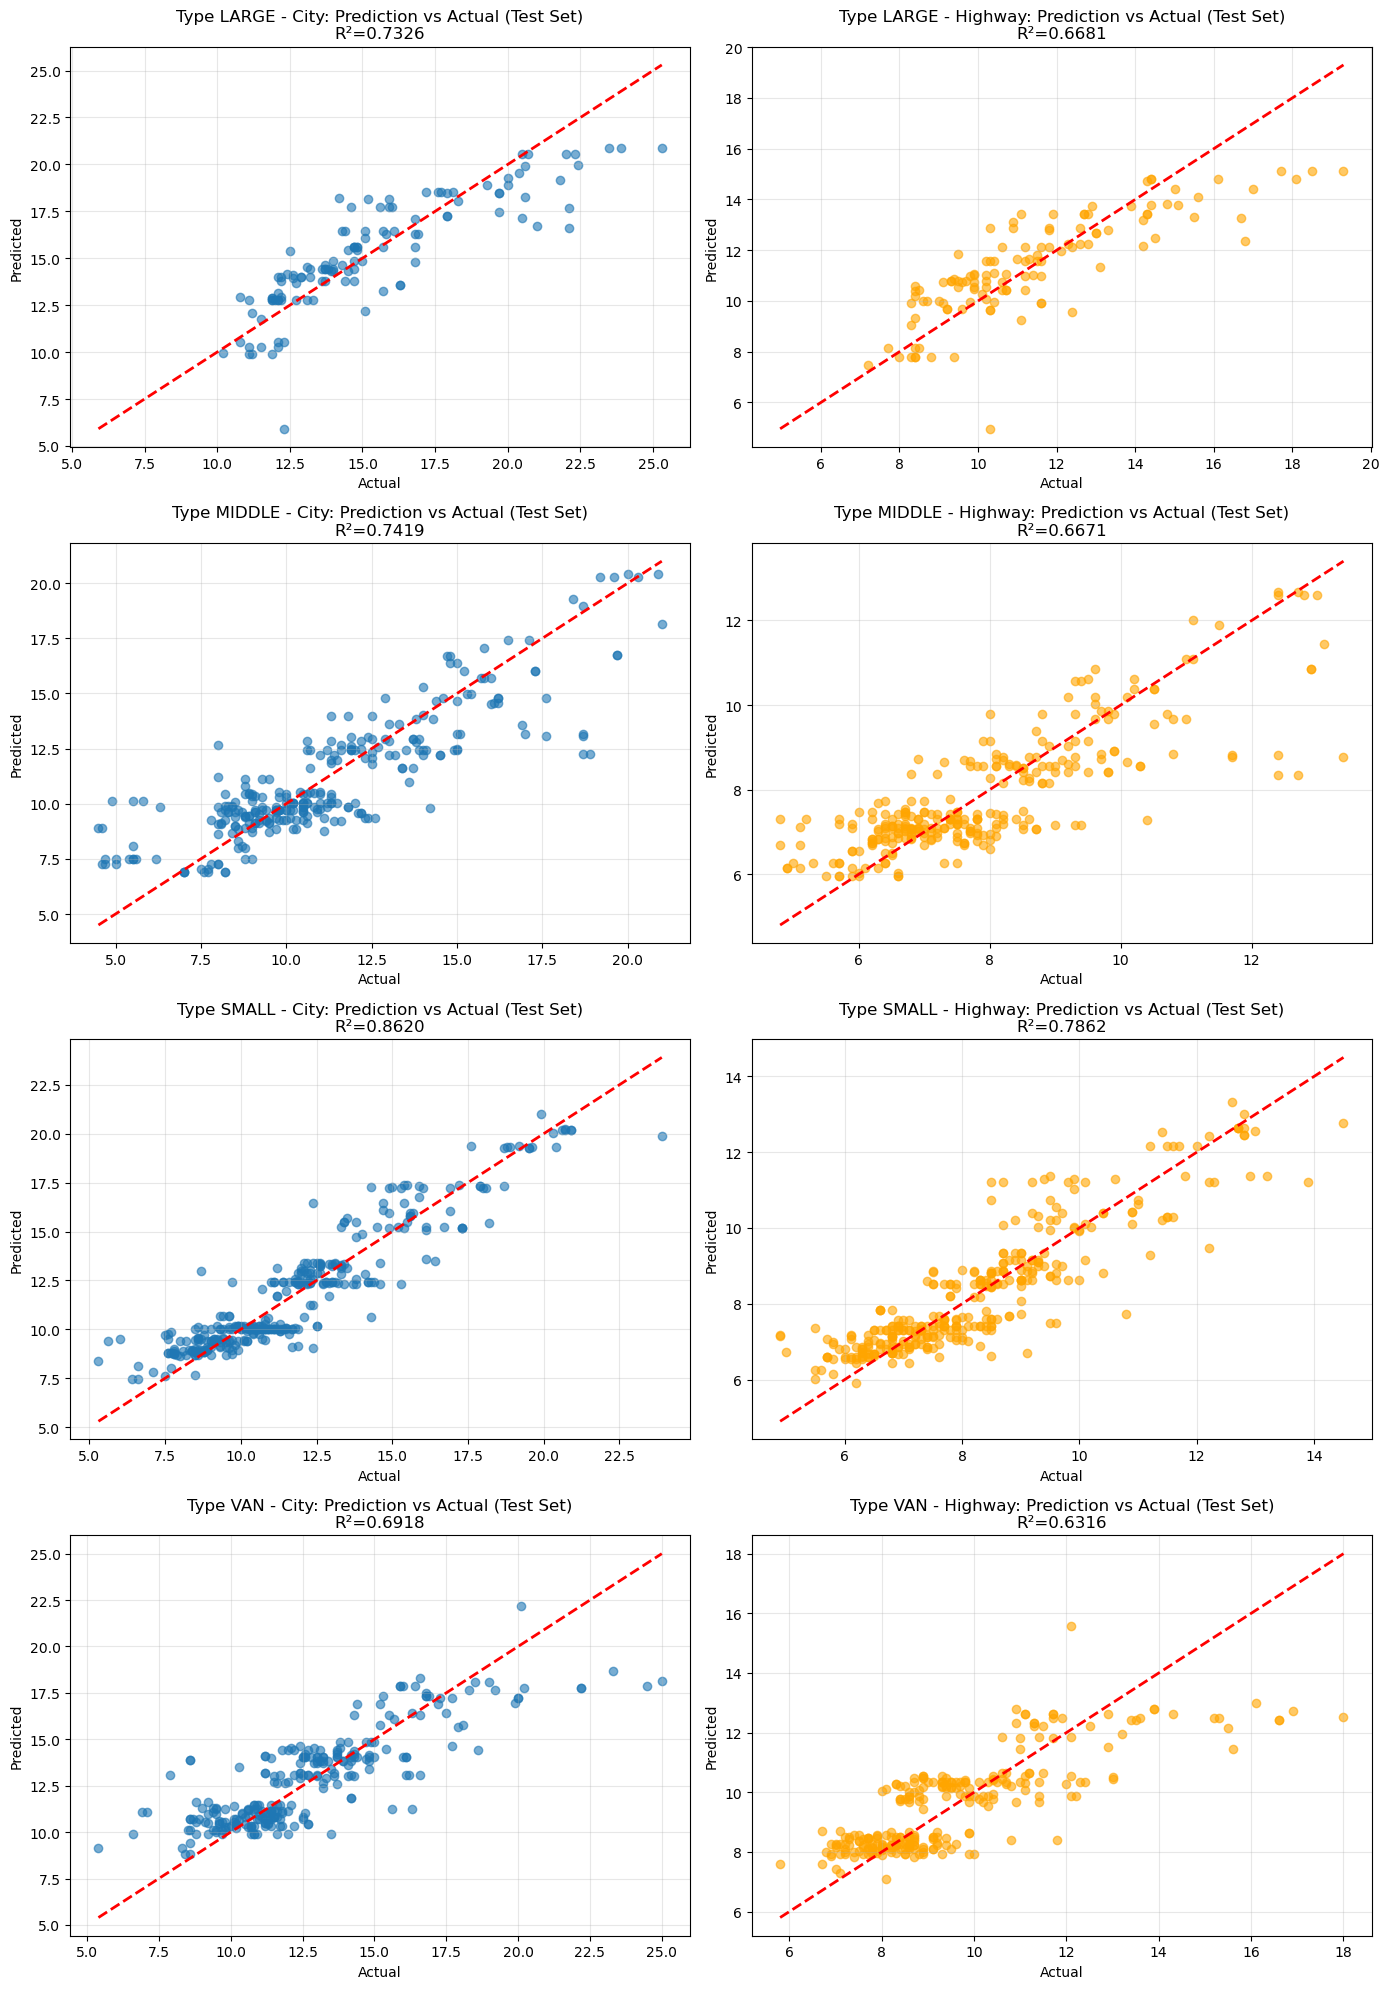

In [ ]:
# Prediction vs Actual on Test Sets
fig, axes = plt.subplots(len(results_summary), 2, figsize=(14, 5*len(results_summary)))
if len(results_summary) == 1:
    axes = axes.reshape(1, -1)

for idx, type_val in enumerate(sorted(results_summary.keys())):
    results = results_summary[type_val]
    
    # City Model - Prediction vs Actual
    ax1 = axes[idx, 0]
    y_test = results['y_city_test']
    y_pred = results['y_city_test_pred']
    min_val = min(y_pred.min(), y_pred.min())
    max_val = max(y_pred.max(), y_pred.max())
    ax1.scatter(y_test, y_pred, alpha=0.6)
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax1.set_xlabel('Actual')
    ax1.set_ylabel('Predicted')
    ax1.set_title(f'Type {type_val} - City: Prediction vs Actual (Test Set)\nR²={results["city"]["r2_test"]:.4f}')
    ax1.grid(True, alpha=0.3)
    
    # Highway Model - Prediction vs Actual
    ax2 = axes[idx, 1]
    y_test = results['y_hwy_test']
    y_pred = results['y_hwy_test_pred']
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax2.scatter(y_test, y_pred, alpha=0.6, color='orange')
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax2.set_xlabel('Actual')
    ax2.set_ylabel('Predicted')
    ax2.set_title(f'Type {type_val} - Highway: Prediction vs Actual (Test Set)\nR²={results["hwy"]["r2_test"]:.4f}')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Residual Plots on Training Sets (Linear Regression)

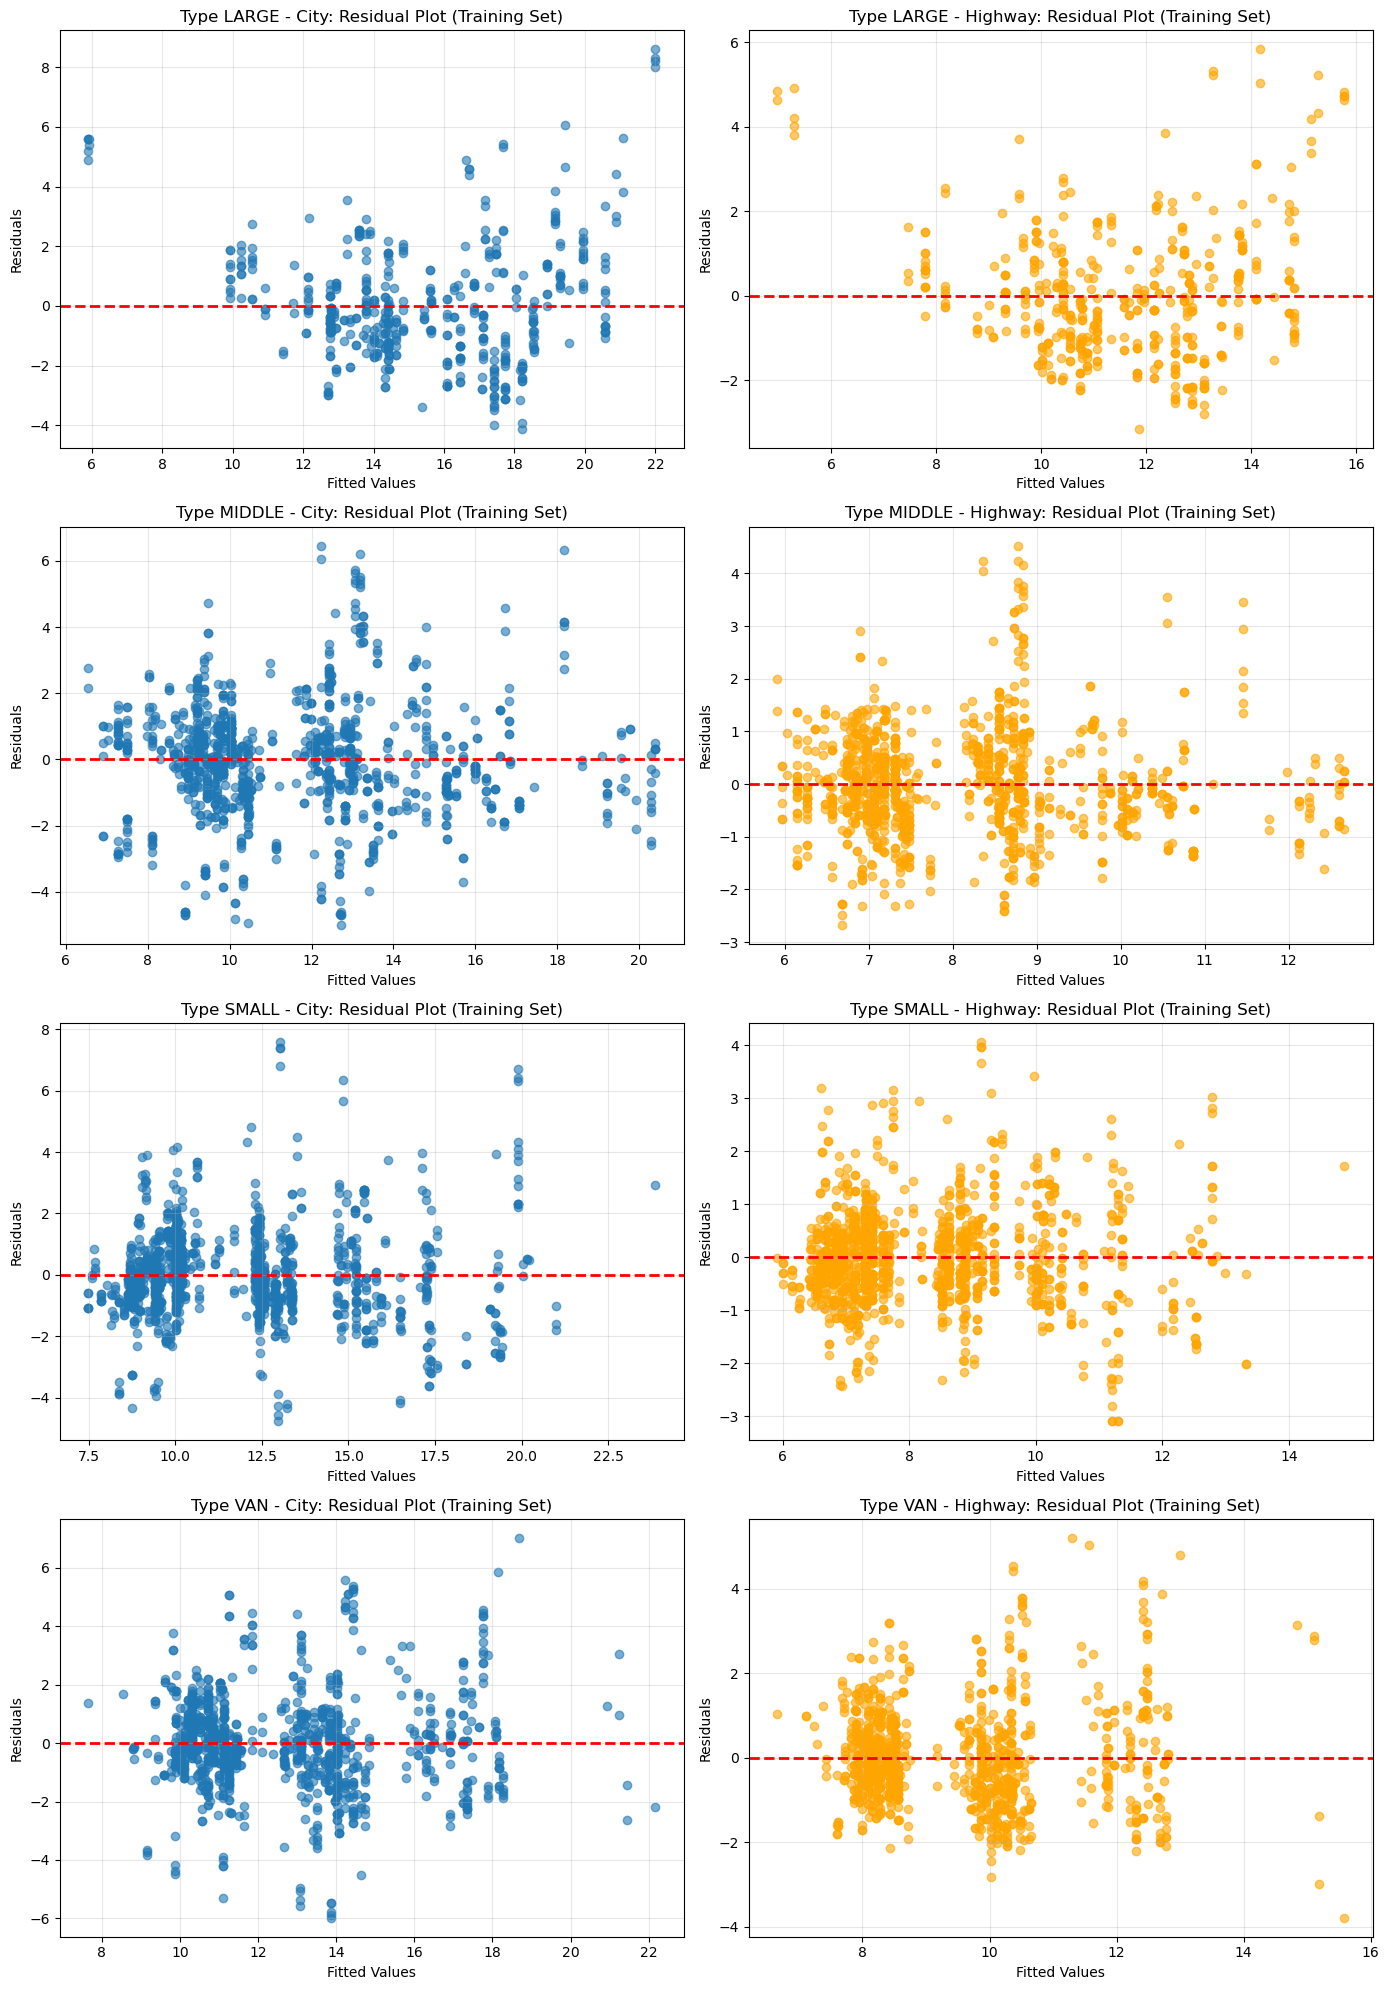

In [13]:
# Residual Plots on Training Sets for Linear Regression Models
fig, axes = plt.subplots(len(results_summary), 2, figsize=(14, 5*len(results_summary)))
if len(results_summary) == 1:
    axes = axes.reshape(1, -1)

for idx, type_val in enumerate(sorted(results_summary.keys())):
    results = results_summary[type_val]
    
    # City Model - Residuals
    ax1 = axes[idx, 0]
    y_train = results['y_city_train']
    y_train_pred = results['y_city_train_pred']
    residuals_city = y_train - y_train_pred
    ax1.scatter(y_train_pred, residuals_city, alpha=0.6)
    ax1.axhline(y=0, color='r', linestyle='--', lw=2)
    ax1.set_xlabel('Fitted Values')
    ax1.set_ylabel('Residuals')
    ax1.set_title(f'Type {type_val} - City: Residual Plot (Training Set)')
    ax1.grid(True, alpha=0.3)
    
    # Highway Model - Residuals
    ax2 = axes[idx, 1]
    y_train = results['y_hwy_train']
    y_train_pred = results['y_hwy_train_pred']
    residuals_hwy = y_train - y_train_pred
    ax2.scatter(y_train_pred, residuals_hwy, alpha=0.6, color='orange')
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel('Fitted Values')
    ax2.set_ylabel('Residuals')
    ax2.set_title(f'Type {type_val} - Highway: Residual Plot (Training Set)')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Summary Results Table

In [ ]:
# Create comprehensive summary table
summary_data = []
for type_val in sorted(results_summary.keys()):
    results = results_summary[type_val]
    summary_data.append({
        'Type': type_val,
        'City_R2_Train': f"{results['city']['r2_train']:.4f}",
        'City_R2_Test': f"{results['city']['r2_test']:.4f}",
        'City_RMSE_Train': f"{results['city']['rmse_train']:.4f}",
        'City_RMSE_Test': f"{results['city']['rmse_test']:.4f}",
        'Highway_R2_Train': f"{results['hwy']['r2_train']:.4f}",
        'Highway_R2_Test': f"{results['hwy']['r2_test']:.4f}",
        'Highway_RMSE_Train': f"{results['hwy']['rmse_train']:.4f}",
        'Highway_RMSE_Test': f"{results['hwy']['rmse_test']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*150)
print("MODEL PERFORMANCE SUMMARY FOR ALL VEHICLE TYPES")
print("="*150)
print(summary_df.to_string(index=False))
print("="*150)

#### Efficient car types

#### Top 10 Most Efficient Cars by Type (City and Highway)

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from IPython.display import display

# Load encoded dataset used for model training
analysis_df = pd.read_csv('Use dataset.csv')

city_target = 'Fuel Consumption City (L/100 km)'
hwy_target = 'Fuel Consumption Hwy (L/100 km)'
feature_cols = [c for c in analysis_df.columns if c not in ['Type', city_target, hwy_target]]

efficiency_tables = {}

for type_val in sorted(analysis_df['Type'].unique()):
    df_type = analysis_df[analysis_df['Type'] == type_val].copy()
    X = df_type[feature_cols]

    for mode_name, target_col in [('city', city_target), ('hwy', hwy_target)]:
        y = df_type[target_col]

        # Use out-of-fold predictions to rank efficiency without training on the same row
        if len(df_type) >= 3:
            n_splits = min(5, len(df_type))
            cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', LinearRegression())
            ])
            preds = cross_val_predict(pipe, X, y, cv=cv)
        else:
            # Fallback for tiny groups
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', LinearRegression())
            ])
            preds = pipe.fit(X, y).predict(X)

        ranked = df_type.copy()
        ranked['Predicted'] = preds
        ranked['Actual'] = y.values
        ranked['Efficiency Gap'] = ranked['Predicted'] - ranked['Actual']
        ranked = ranked[ranked['Efficiency Gap'] > 0].sort_values('Efficiency Gap', ascending=False).head(10)

        out_cols = ['Type'] + feature_cols + ['Actual', 'Predicted', 'Efficiency Gap']
        efficiency_tables[(type_val, mode_name)] = ranked[out_cols].reset_index(drop=True)

# Display top 10 efficient cars for each type and driving condition
for type_val in sorted(analysis_df['Type'].unique()):
    print(f"\n{'=' * 90}")
    print(f"TYPE: {type_val} | CITY")
    print(f"{'=' * 90}")
    display(efficiency_tables[(type_val, 'city')])

    print(f"\n{'=' * 90}")
    print(f"TYPE: {type_val} | HIGHWAY")
    print(f"{'=' * 90}")
    display(efficiency_tables[(type_val, 'hwy')])